In [29]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from transformers import ViTForImageClassification

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [31]:
TEST_DIR = r"D:\new03\herb-recognition\dataset\test"


In [32]:
assert os.path.exists(TEST_DIR)

print("Folders inside test:")
for f in os.listdir(TEST_DIR):
    print(" -", f)


Folders inside test:
 - Acorus_calamus
 - Adhatoda_vasica
 - Aegle_marmelos
 - Ailanthus_excelsa
 - Allium_cepa
 - Allium_sativum
 - Aloe_vera
 - Alpinia_galanga
 - Andrographis_paniculata
 - Anethum_graveolens
 - Artemisia_absinthium
 - Asparagus_racemosus
 - Azadirachta_indica
 - Bacopa_monnieri
 - Berberis_aristata
 - Boerhavia_diffusa
 - Boswellia_serrata
 - Brassica_juncea
 - Butea_monosperma
 - Calendula_officinalis
 - Carum_carvi
 - Cassia_fistula
 - Celastrus_paniculatus
 - Centella_asiatica
 - Cinnamomum_verum
 - Cissus_quadrangularis
 - Clitoria_ternatea
 - Commiphora_mukul
 - Convolvulus_pluricaulis
 - Cordia_dichotoma
 - Coriandrum_sativum
 - Cuminum_cyminum
 - Curcuma_longa
 - Cymbopogon_citratus
 - Cymbopogon_flexuosus
 - Desmodium_gangeticum
 - Eclipta_prostrata
 - Elettaria_cardamomum
 - Emblica_officinalis
 - Ferula_asafoetida
 - Foeniculum_vulgare
 - Fumaria_indica
 - Glycyrrhiza_glabra
 - Gymnema_sylvestre
 - Hedychium_spicatum
 - Hemidesmus_indicus
 - Holarrhena_ant

In [33]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])


In [34]:
def is_image_file(path):
    return path.lower().endswith(('.jpg', '.jpeg', '.png'))

test_dataset = ImageFolder(
    root=TEST_DIR,
    transform=transform,
    is_valid_file=is_image_file
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

class_names = test_dataset.classes
num_classes = len(class_names)

print("Classes detected:", class_names)
print("Number of classes:", num_classes)


Classes detected: ['Acorus_calamus', 'Adhatoda_vasica', 'Aegle_marmelos', 'Ailanthus_excelsa', 'Allium_cepa', 'Allium_sativum', 'Aloe_vera', 'Alpinia_galanga', 'Andrographis_paniculata', 'Anethum_graveolens', 'Artemisia_absinthium', 'Asparagus_racemosus', 'Azadirachta_indica', 'Bacopa_monnieri', 'Berberis_aristata', 'Boerhavia_diffusa', 'Boswellia_serrata', 'Brassica_juncea', 'Butea_monosperma', 'Calendula_officinalis', 'Carum_carvi', 'Cassia_fistula', 'Celastrus_paniculatus', 'Centella_asiatica', 'Cinnamomum_verum', 'Cissus_quadrangularis', 'Clitoria_ternatea', 'Commiphora_mukul', 'Convolvulus_pluricaulis', 'Cordia_dichotoma', 'Coriandrum_sativum', 'Cuminum_cyminum', 'Curcuma_longa', 'Cymbopogon_citratus', 'Cymbopogon_flexuosus', 'Desmodium_gangeticum', 'Eclipta_prostrata', 'Elettaria_cardamomum', 'Emblica_officinalis', 'Ferula_asafoetida', 'Foeniculum_vulgare', 'Fumaria_indica', 'Glycyrrhiza_glabra', 'Gymnema_sylvestre', 'Hedychium_spicatum', 'Hemidesmus_indicus', 'Holarrhena_antidys

In [35]:
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=100,
    ignore_mismatched_sizes=True
)

model.load_state_dict(
    torch.load("model/vit_herb_model.pth", map_location=device)
)

model.to(device)
model.eval()


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([100]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([100, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [36]:
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())


In [37]:
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 96.89%


In [38]:
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1-score: {f1 * 100:.2f}%")

Precision: 97.05%
Recall: 96.89%
F1-score: 96.75%


In [39]:
labels = sorted(list(set(y_true) | set(y_pred)))

report = classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=[class_names[i] if i < len(class_names) else f"Unknown_{i}" for i in labels],
    zero_division=0
)

print(report)

                            precision    recall  f1-score   support

            Acorus_calamus       1.00      1.00      1.00        19
           Adhatoda_vasica       0.50      0.16      0.24        19
            Aegle_marmelos       1.00      0.79      0.88        19
         Ailanthus_excelsa       1.00      1.00      1.00        19
               Allium_cepa       1.00      1.00      1.00        19
            Allium_sativum       1.00      1.00      1.00        19
                 Aloe_vera       1.00      1.00      1.00        19
           Alpinia_galanga       1.00      1.00      1.00        19
   Andrographis_paniculata       1.00      1.00      1.00        19
        Anethum_graveolens       0.90      1.00      0.95        19
      Artemisia_absinthium       1.00      0.95      0.97        19
       Asparagus_racemosus       1.00      1.00      1.00        19
        Azadirachta_indica       0.83      1.00      0.90        19
           Bacopa_monnieri       1.00      1.00

In [40]:
cm = confusion_matrix(y_true, y_pred)
import numpy as np
np.set_printoptions(threshold=np.inf)

print(cm)

[[19  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0]
 [ 0  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0]
 [ 0  0 15  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  1  0  0]
 [ 0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0

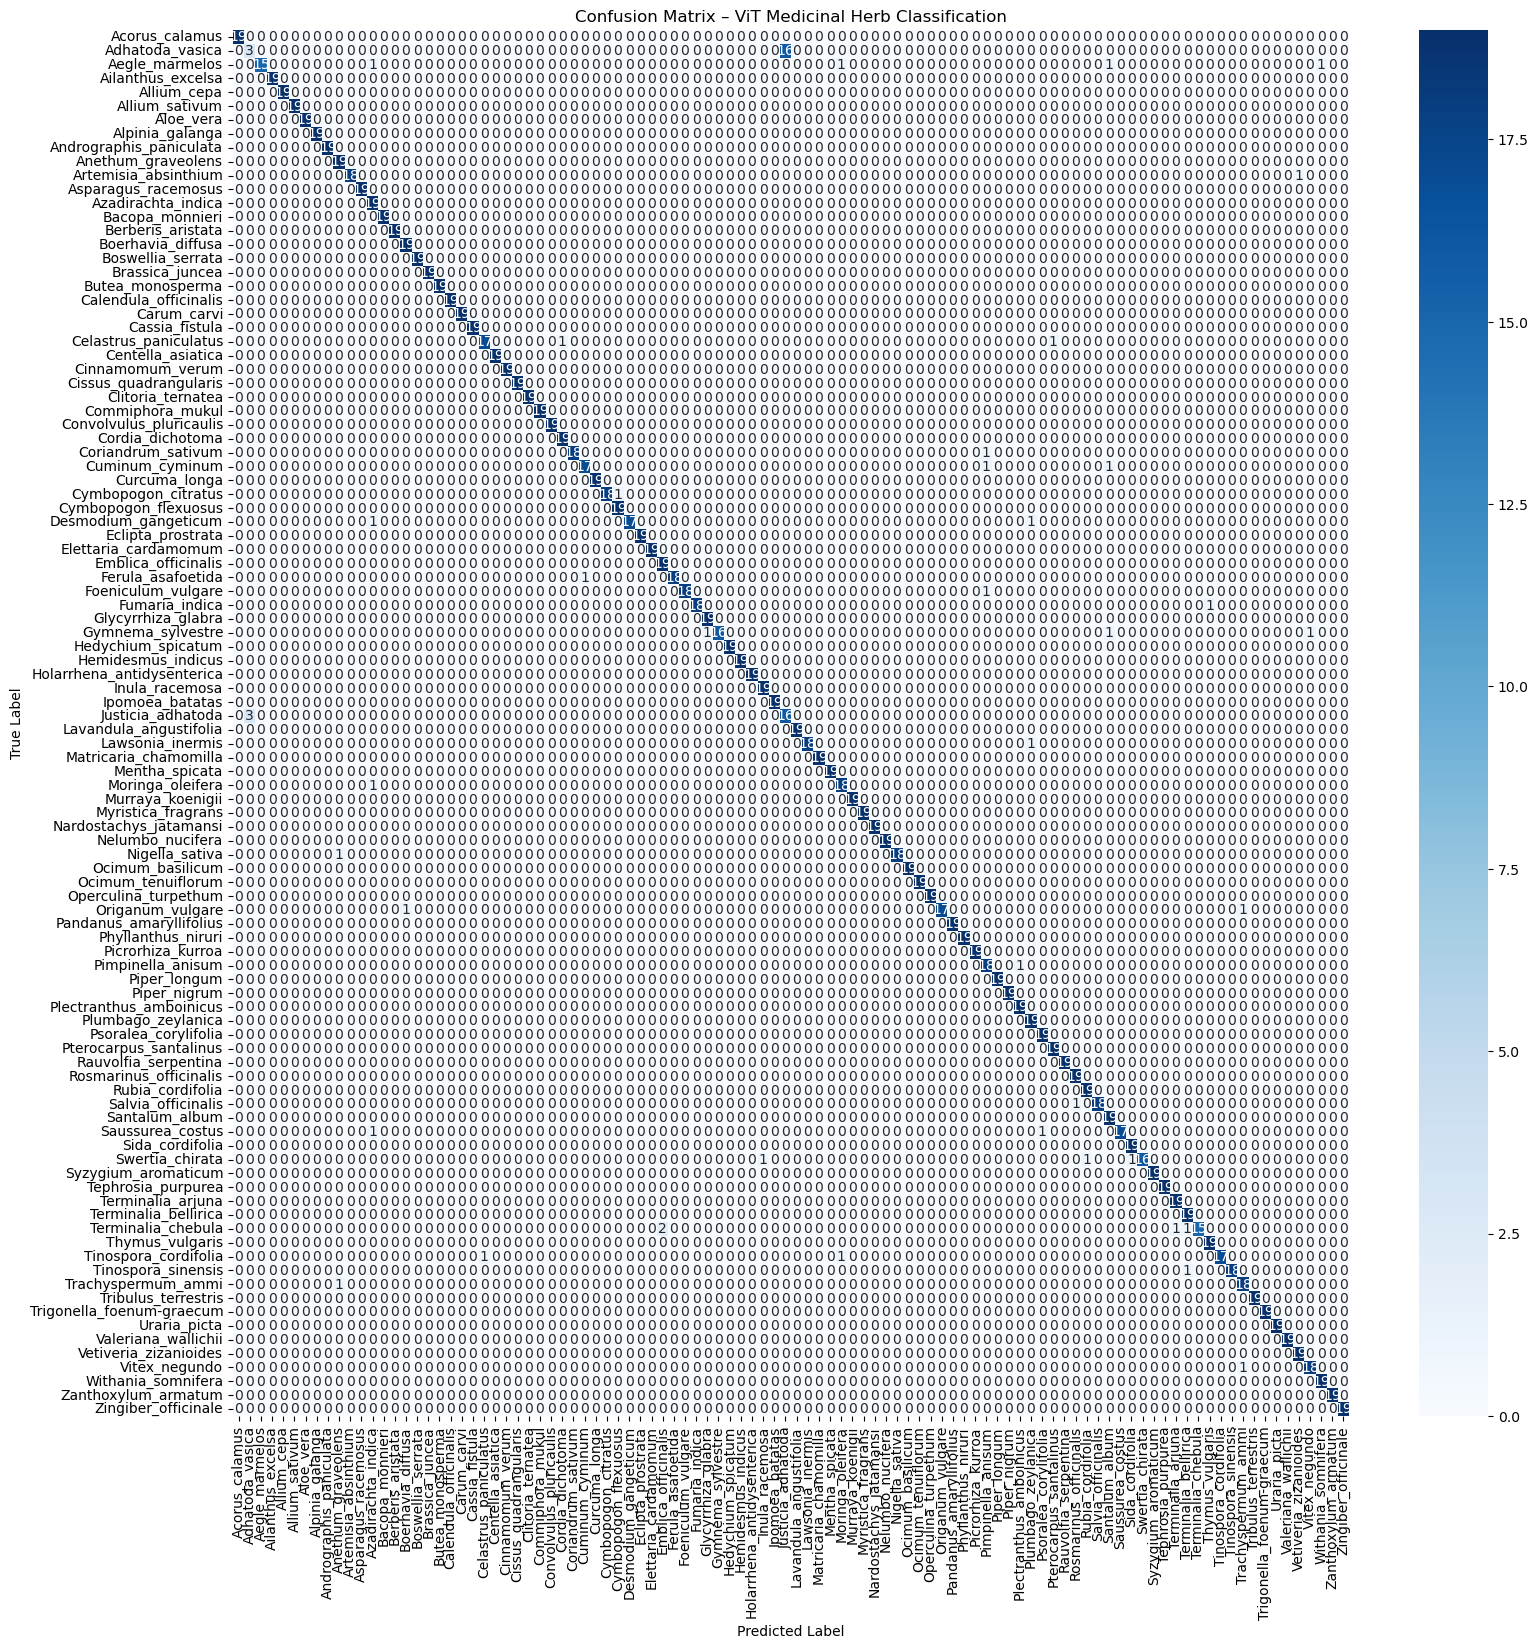

In [41]:
# plt.figure(figsize=(20, 20))

# sns.heatmap(
#     cm,
#     cmap="Blues",
#     square=True,
#     cbar=True,
#     xticklabels=class_names,
#     yticklabels=class_names
# )

# plt.xticks(rotation=90, fontsize=6)
# plt.yticks(rotation=0, fontsize=6)

# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.title("Confusion Matrix – ViT Medicinal Herb Classification")

# plt.tight_layout()
# plt.show()

plt.figure(figsize=(18, 18))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – ViT Medicinal Herb Classification")
plt.show()


In [42]:
print("FINAL EVALUATION METRICS")
print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1-score  : {f1 * 100:.2f}%")

FINAL EVALUATION METRICS
Accuracy  : 96.89%
Precision : 97.05%
Recall    : 96.89%
F1-score  : 96.75%
